In [2]:
import math
import snappy
import pandas as pd
from khovanov import *
from knot_graphs import *

In [3]:
def draw_movie(M):
    for l in M.links:
        draw_adjacency_graph(l)
        plt.show()

# Finding Band moves from $T(4,n)$ (small $n$) to the unknot $\mathcal{U}$

### TODO
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot
- Fix $T(4,n)$ for small $n$ and do non-pinch moves + have snappy idenfity resulting knots
    - Check $e=w-w'$ and ignore $e=0$ (these are orientable band moves)

In [4]:
T45 = snappy.Link('T(4,5)')

In [5]:
G = adjacency_graph(T45)
G.nodes

NodeView(((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2), (4, 0), (4, 1), (4, 2)))

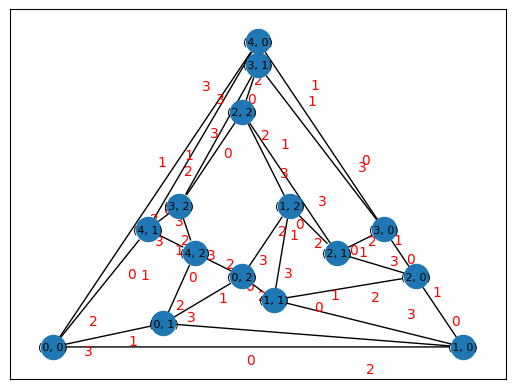

In [6]:
draw_adjacency_graph(T45, rad_increment=0.2)

In [7]:
T45.view()

In [8]:
%gui tk

## 

Lemma 2.1. ([Sabloff](https://arxiv.org/pdf/2206.11200))

The result of applying a pinch move to $T(p,q)$ is the torus knot $T(p-2t,q-2u)$ where
$$
\begin{cases}
t \equiv -q^{-1}\bmod p, \\
u \equiv p^{-1}\bmod q.
\end{cases}
$$
Let's see what the resulting knots look like.

In [9]:
def pinch_result(p,q):
    t = (pow(q, -1, p) * -1) % p
    u = pow(p, -1, q)
    if t < 0:
        t += p
    return p-2*t, q-2*u

In [23]:
inputs = []
outputs = []
for p in range(5, 20):
    if math.gcd(p,4) != 1:
        continue

    p_prime, q_prime = pinch_result(p, 4)
    p_prime1, q_prime1 = pinch_result(4,p)
    inputs.append(f'T({p},4)')
    if (p_prime > 0 and q_prime > 0):
        outputs.append(f'T({p_prime},{q_prime})')
    elif (p_prime1 > 0 and p_prime1 > 0):
        outputs.append(f'T({q_prime1},{p_prime1})')
    else:
        print(f"can't find valid result for T({p},4)/T(4,{p})")

pd.DataFrame(zip(inputs, outputs), columns=['Knot', 'Result after pinch move'])

,Knot,Result after pinch move
0,"T(5,4)","T(3,2)"
1,"T(7,4)","T(3,2)"
2,"T(9,4)","T(5,2)"
3,"T(11,4)","T(5,2)"
4,"T(13,4)","T(7,2)"
5,"T(15,4)","T(7,2)"
6,"T(17,4)","T(9,2)"
7,"T(19,4)","T(9,2)"


We also have the following.

Lemma 2.3. (Sabloff)
If $T(p,q)$ is transformed to $T(p_0,1)$ in the construction of the pinch surface $F(p,q)$ then
$$
e(F(p,q)) = p_0 - pq.
$$

### TODO - use this to correctly compute $e(F(p,q))$ for pinch moves

## Compute normal euler numbers + identify results of pinch moves

### TODO - do we need `extends_to_link=True`?
"If the flag “extends_to_link” is True, requires that the isometry sends meridians to meridians. If the input manifold is closed this will result in no matches being returned."

### TODO - do we need `with_hyperbolic_structure=True`?

In [11]:
def find_bands(K, cutoff=100):
    if cutoff is None:
        import sys
        cutoff = sys.maxint
    
    num_crossings = len(K.crossings)

    snappy_K = snappy.Link(K.PD_code())
    writhe = snappy_K.writhe()

    c0s = []
    c1s = []
    s0s = []
    s1s = []
    es = []
    results = []
    
    i = 0
    cutoff_reached = False
    for c0 in range(num_crossings):
        if cutoff_reached: break
        for c1 in range(num_crossings):
            if cutoff_reached: break
            for s0 in range(4):
                if cutoff_reached: break
                for s1 in range(4):
                    if i >= cutoff:
                        cutoff_reached = True
                    if cutoff_reached: break
                    
                    c0s.append(c0)
                    c1s.append(c1)
                    s0s.append(s0)
                    s1s.append(s1)
                    
                    S = Cobordism(K)
                    i += 1
                    try:
                        S.band_move(1, (c0, s0), (c1, s1))
                        S.finish()

                        K_prime = S.links[-1]
                        snappy_K_prime = snappy.Link(K_prime.PD_code())
                        
                        writhe_prime = snappy_K_prime.writhe()
                        normal_euler = writhe - writhe_prime
                        es.append(normal_euler)

                        complement = snappy_K_prime.exterior()
                        result = complement.identify()
                        results.append(result)
                    except:
                        continue

    return pd.DataFrame(zip(c0s, s0s, c1s, s1s, es, results), columns=['c0', 's0', 'c1', 's1', 'e', 'resulting knot'])

### TODO - identify when `S.finish()` fails vs. when snappy cannot identify `K_prime`

In [22]:
T45_link = Link(T45.PD_code())
df = find_bands(T45_link, cutoff=100)
df

,c0,s0,c1,s1,e,resulting knot
0,0,0,0,0,0,[]
1,0,0,0,1,11,"[v0600(0,0), K7_25(0,0)]"
2,0,0,0,2,0,[]
3,0,0,0,3,13,[]
4,0,1,0,0,0,[]
5,0,1,0,1,11,"[v0600(0,0), K7_25(0,0)]"
6,0,1,0,2,13,[]
7,0,1,0,3,0,[]
8,0,2,0,0,1,[]
9,0,2,0,1,0,[]


### TODO - euler number should be even

### TODO - $e(F) \equiv 2 \chi(F) \bmod 4$

In [21]:
T45.writhe()

15

In [14]:
S = Cobordism(T45_link)
S.band_move(1, (0,0), (0,1))
S.finish()

In [17]:
K = snappy.Link(S.links[-1].PD_code())
K.writhe()

4

In [19]:
K.view()

In [20]:
K.exterior().identify()

[v0600(0,0), K7_25(0,0)]

### TODO - we know that $F(p,q)$ gives us the minimum $b_1$ for a vertical slice of the wedge region determined by $p,q$. We want to find other band moves from $T(p,q)$ that give us the same $b_1$.

Geometrically, we want to find other realizable points on the horizontal line.
They necessarily have to be realized by non-pinch moves.

We have the width of the signature bound given by:
$$
\left| \sigma - \frac{e}{2} \right| \le b_1
$$
for fixed $b_1\in\mathbb{N}$